In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import rioxarray
import matplotlib.pyplot as plt
import os
import dask
import dask.array

import datetime

from collections import Counter

import pystac_client
from pystac.extensions.projection import ProjectionExtension as proj

import planetary_computer
import rasterio
import rasterio.features
from rasterio.features import rasterize

import stackstac
import pyproj

import dask.diagnostics

from shapely.geometry import box
from shapely.ops import transform

from scipy.ndimage import binary_propagation
from scipy.ndimage import label



In [2]:
## OPEN PREVIOUSLY-CREATED ARRAY FROM DISK

stack_name = "tiles_wk"
ds = xr.open_zarr(f"/home/jupyter/{stack_name}.zarr", chunks="auto")
tiles_reload = ds[f'{stack_name}']
tiles_reload

<xarray.DataArray 'tiles_wk' (time: 22, band: 5, y: 2048, x: 2048)> Size: 4GB
dask.array<open_dataset-tiles_wk, shape=(22, 5, 2048, 2048), dtype=float64, chunksize=(3, 1, 256, 512), chunktype=numpy.ndarray>
Coordinates: (12/19)
  * band                                     (band) <U3 60B 'B04' ... 'B11'
    center_wavelength                        (band) float64 40B dask.array<chunksize=(5,), meta=np.ndarray>
    common_name                              (band) <U6 120B dask.array<chunksize=(5,), meta=np.ndarray>
    constellation                            <U10 40B ...
    epsg                                     int64 8B ...
    full_width_half_max                      (band) float64 40B dask.array<chunksize=(5,), meta=np.ndarray>
    ...                                       ...
    s2:product_type                          <U7 28B ...
    s2:saturated_defective_pixel_percentage  float64 8B ...
  * time                                     (time) datetime64[ns] 176B 2019-...
    title                                    (band) <U26 520B dask.array<chunksize=(5,), meta=np.ndarray>
  * x                                        (x) float64 16kB 5.507e+05 ... 5...
  * y                                        (y) float64 16kB 7.635e+06 ... 7...
Attributes:
    crs:         epsg:32622
    resolution:  10
    transform:   [10.0, 0.0, 549970.0, 0.0, -10.0, 7635420.0, 0.0, 0.0, 1.0]

In [16]:
# COMPUTE BAND MATH FOR WATER (NDWI, MNDWI, BmG, BmR/BpR)

# WATER INDICES AND MASKS
NDWI = (tiles_reload.sel(band="B02")-tiles_reload.sel(band="B08")) / (tiles_reload.sel(band="B02")+tiles_reload.sel(band="B08"))
NDWI = NDWI.fillna(0.0)
mask_NDWI = xr.where(NDWI >= 0.1, 1.0, 0.0)

MNDWI = (tiles_reload.sel(band="B02") - tiles_reload.sel(band="B11"))/(tiles_reload.sel(band="B02") + tiles_reload.sel(band="B11"))
MNDWI = MNDWI.fillna(0.0)

BmG = (tiles_reload.sel(band="B02")-tiles_reload.sel(band="B03")) / 10000
BmG = BmG.fillna(0.0)

BmR_BpR = (tiles_reload.sel(band="B02")-tiles_reload.sel(band="B04")) / (tiles_reload.sel(band="B02")+tiles_reload.sel(band="B04"))
BmR_BpR = BmR_BpR.fillna(0.0)



In [1]:
## CREATE WATER-TRACKER GRID OF SUBTILES THAT AVERAGE THE 

# size of each subtile
BY=BX=16

# compute 
subtile_sums = (
    mask_NDWI
      .coarsen(y=BY, x=BX, boundary="trim")  # chop into subtiles of given size BY=BX
      .sum()                                  # sum within each subtile
)

print(f"subtile grids created with shape: {subtile_sums.shape}")


NameError: name 'mask_NDWI' is not defined

In [30]:
## MASKS WATER MOVEMENT PIXELS TO HAVE ID OF LAKE

tiles = subtile_sums
da0   = tiles.isel(time=0)

# Read your vector and pick the subset you care about
gdf = gpd.read_file("/home/jupyter/repos/lake-vision/sandbox/dunmire_cw2019_shuttle.geojson")
gdf = gdf.to_crs(tiles_reload.rio.crs)  # make sure it’s in the same CRS

# Create a numeric code for each lake
#   You can either use a simple 1…N index…
gdf["lake_id"] = np.arange(1, len(gdf) + 1)

# …or map your string “lakenum” to an integer if you want:
# unique_vals = gdf["lakenum"].unique()
# id_map = {val: i+1 for i, val in enumerate(unique_vals)}
# gdf["lake_id"] = gdf["lakenum"].map(id_map)

# Build the shapes iterator: (geometry, lake_id)
shapes = ((geom, lid) for geom, lid in zip(gdf.geometry, gdf.lake_id))

# Rasterize into an integer mask
mask_arr = rasterize(
    shapes,
    out_shape=da0.rio.shape,
    transform=da0.rio.transform(),
    fill=0,        # 0 = “no lake”
    dtype="uint16" # or larger if you have >65535 lakes
)

# Wrap back into an xarray
lake_id_mask = xr.DataArray(
    mask_arr,
    dims=("y", "x"),
    coords={"y": da0.y, "x": da0.x},
    name="lake_id_mask",
)
# (Optional) broadcast if you need the time dims:
full_mask = lake_id_mask\
    .expand_dims(time=tiles.time)\
    .transpose("time","y","x")

# If you want to remember which integer maps to which lakenum:
lake_id_mask.attrs["id_to_lakenum"] = dict(zip(gdf.lake_id, gdf.lakenum))

# print(lake_id_mask)
# print("Legend:", lake_id_mask.attrs["id_to_lakenum"])
print(f"full_mask.shape: {full_mask.shape}")

# GET A LIST OF LAKES THAT ARE PRESENT IN THE CURRENT SCENE

lakes_in_scene = np.unique(full_mask)[1:]
print(f"lake numbers in the current scene: {lakes_in_scene}")



full_mask.shape: (22, 128, 128)
lake numbers in the current scene: [  9  10  26 312 317 318 323 331 338 354 355 360 361 363 366 367 368 369
 378 380 394 395 396 441 447 460 461 484]


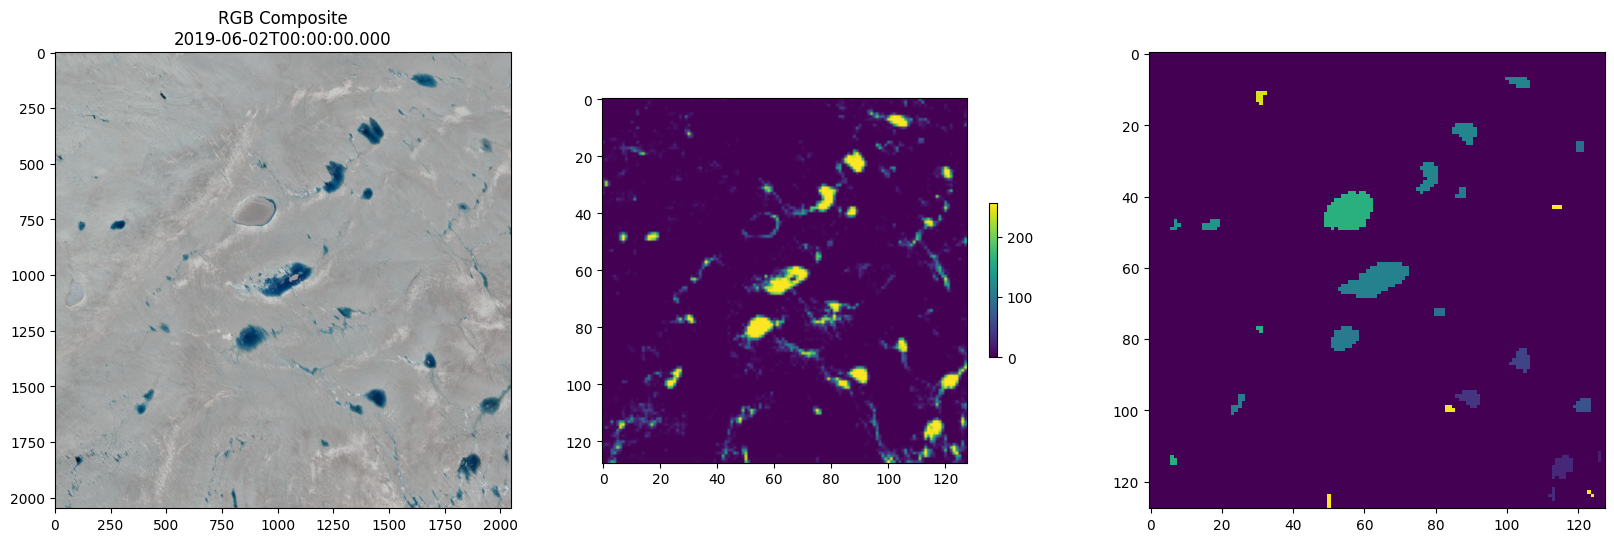

In [34]:
## PLOT RGB, SUBTILE GRID, LAKE IDs

idx_date = 4

plt.figure(figsize=(20,20))
plt.subplot(1,3,1)
img3 = tiles_reload.isel(time=idx_date, band=[0,1,2]).values   # shape (3, H, W)
rgb = np.moveaxis(img3, 0, -1)
plt.imshow(rgb)
plt.title(f"RGB Composite\n{tiles_reload.isel(time=idx_date, band=[0,1,2]).time.values.astype('datetime64[ms]')}")

plt.subplot(1,3,2)
pathway_threshold = 0
# B = subtile_sums.values[idx_date,] > pathway_threshold
# B_dilated = binary_dilation(B, structure=kernel, iterations=1)
# plt.imshow(B)
plt.imshow(subtile_sums[idx_date,])
plt.colorbar(shrink=0.1)
# plt.colorbar()

plt.subplot(1,3,3)
plt.imshow(full_mask[idx_date,])
plt.clim(300, 450)



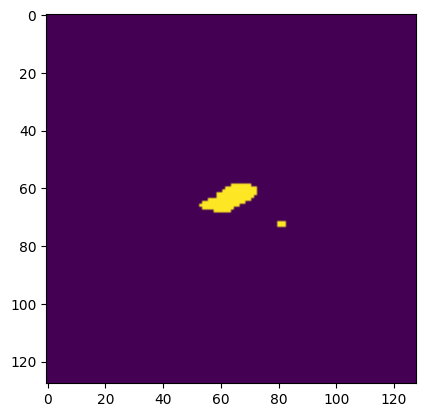

In [32]:
lbl = full_mask[idx_date,]

lake1 = 366
lake2 = 355

twolakes = (lbl == lake1) | (lbl == lake2)

plt.imshow(twolakes)



In [35]:
## DEFINE FUNCTION FOR CHECKING CONNECTIVITY OF TWO LAKES

def lake_conn(idx_lake1, idx_lake2, idx_date, mask_lakeIDs, watergrid, thresh_watergrid):
    
    lbl = mask_lakeIDs[0,]
    
    A = (lbl == lake1) | (lbl == lake2)
    B = watergrid.values[idx_date,]>thresh_watergrid
    
    # label the two islands in A
    islands, n_islands = label(A, structure=np.ones((3,3),bool))
    if n_islands != 2:
        raise ValueError(f"Expected exactly 2 islands in A, got {n_islands}")
        
    # mask for island1
    seed = (islands == 1)

    # allow flooding on both walkway B and island2 itself
    flood_mask = (B==1) | (islands == 2)

    # flood from seed, using 8-connectivity
    reach = binary_propagation(seed, structure=np.ones((3,3),bool), mask=flood_mask)

    # if any pixel of island2 is reached, they’re connected
    connected = np.any( reach & (islands == 2) )
    
    return connected



In [75]:
## USE FUNCTION ON A GIVEN PAIR OF LAKES ON A GIVEN DATE

connected = lake_conn(366, 355, idx_date=5, mask_lakeIDs=full_mask, watergrid=subtile_sums, thresh_watergrid=0)
print(connected)

False


In [ ]:
## USE FUNCTION TO GENERATE ADJACENCY MATRIX FOR A GIVEN DATE

for 


In [49]:
import numpy as np
import itertools
from scipy.ndimage import label

def lake_adjacency(mask_lakeIDs, watergrid, thresh, lakes_in_scene, idx_date):
    """
    Same as before, but convert everything to numpy first so that
    boolean indexing (lbl[mask]) works without xarray errors.
    """
    # 1) grab numpy arrays for this time slice
    #    adjust these two lines to match your actual dims/coords names:
    if hasattr(mask_lakeIDs, "values"):
        lbl = mask_lakeIDs.values[idx_date, ...]
    else:
        lbl = mask_lakeIDs[idx_date, ...]
        
    if hasattr(watergrid, "values"):
        water = watergrid.values[idx_date, ...]
    else:
        water = watergrid[idx_date, ...]

    # 2) build the combined connectivity mask
    water_mask = (water > thresh)
    combined   = water_mask | (lbl > 0)

    # 3) label connected components (8-connectivity)
    comp_id, n_comp = label(combined, structure=np.ones((3,3), bool))

    # 4) prepare output
    lakes = np.array(lakes_in_scene)
    idx_map = {lake: i for i, lake in enumerate(lakes)}
    adj = np.zeros((len(lakes), len(lakes)), dtype=bool)

    # 5) loop over components and connect any lakes that co-occur
    for comp in range(1, n_comp+1):
        mask = (comp_id == comp)
        present = np.unique(lbl[mask])      # now lbl is a NumPy array, so this works
        present = present[present != 0]
        present = np.intersect1d(present, lakes)
        for a, b in itertools.combinations(present, 2):
            i, j = idx_map[a], idx_map[b]
            adj[i, j] = adj[j, i] = True

    return lakes, adj


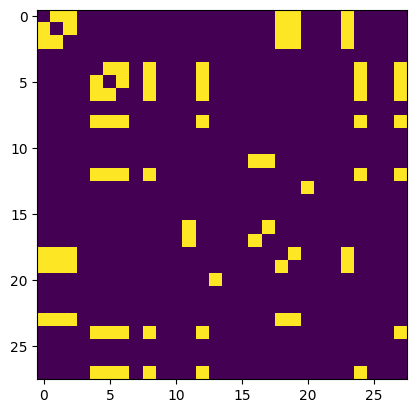

In [76]:

mask_lakeIDs = full_mask
watergrid = subtile_sums
thresh_watergrid = 0
lakes_in_scene = lakes_in_scene

idx_date = 6

lakes, adj = lake_adjacency(mask_lakeIDs, watergrid, thresh_watergrid, lakes_in_scene, idx_date)

plt.imshow(adj)

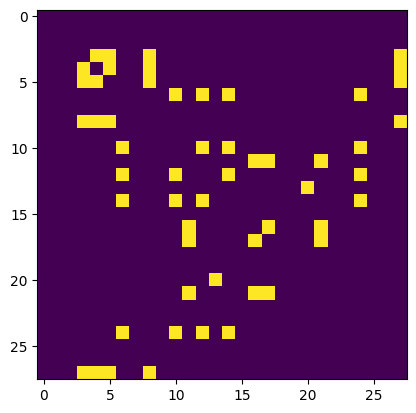

In [74]:
adj[10,14]

np.False_

In [66]:
# lakes is your 1D array or list of lake-IDs,
# adj   is your (n × n) boolean NumPy matrix
df = pd.DataFrame(adj, index=lakes, columns=lakes)

# In Jupyter, this will render as a nice table:
display(df)

# Or, to print to the console:
# print(df)

,9,10,26,312,317,318,323,331,338,354,...,378,380,394,395,396,441,447,460,461,484
9,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
10,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
26,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
312,False,False,False,False,True,True,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True
317,False,False,False,True,False,True,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True
318,False,False,False,True,True,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True
323,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
331,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
338,False,False,False,True,True,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
354,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


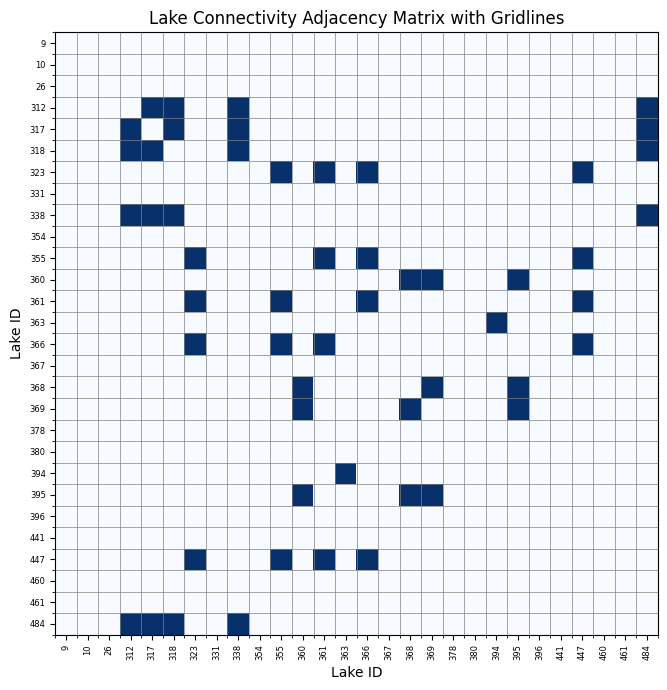

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Recreate your DataFrame
df = pd.DataFrame(adj, index=lakes, columns=lakes)

fig, ax = plt.subplots(figsize=(7, 7))
im = ax.imshow(df.values, aspect='equal', cmap='Blues')

# Major ticks for labeling
ax.set_xticks(np.arange(len(df.columns)))
ax.set_yticks(np.arange(len(df.index)))
ax.set_xticklabels(df.columns, rotation=90, fontsize=6)
ax.set_yticklabels(df.index, fontsize=6)

# Minor ticks for gridlines at cell boundaries
ax.set_xticks(np.arange(-0.5, len(df.columns), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(df.index),   1), minor=True)

# Turn on the grid on those minor ticks
ax.grid(which='minor', color='gray', linestyle='-', linewidth=0.5)

# Optional: hide the outer frame so it lines up nicely
ax.set_xlim(-0.5, len(df.columns)-0.5)
ax.set_ylim(len(df.index)-0.5, -0.5)

ax.set_xlabel('Lake ID')
ax.set_ylabel('Lake ID')
ax.set_title('Lake Connectivity Adjacency Matrix with Gridlines')

plt.tight_layout()
plt.show()


In [33]:

idx_date = 4
pathway_threshold = 0

A = twolakes
B = subtile_sums.values[idx_date,]>pathway_threshold

# 1) label the two islands in A
islands, n_islands = label(A, structure=np.ones((3,3),bool))
if n_islands != 2:
    raise ValueError(f"Expected exactly 2 islands in A, got {n_islands}")

# mask for island1
seed = (islands == 1)

# allow flooding on both walkway B and island2 itself
flood_mask = (B==1) | (islands == 2)

# flood from seed, using 8-connectivity
reach = binary_propagation(seed, structure=np.ones((3,3),bool), mask=flood_mask)

# if any pixel of island2 is reached, they’re connected
connected = np.any( reach & (islands == 2) )
print("Connected?", connected)




Connected? True
